# Midterm Project: Комплексный DL-проект

**Занятие 39 | Неделя 20**

## Задание

Выполните комплексный проект по Deep Learning, используя методы из курса.

**Дедлайн:**
- Презентация (5-6 минут) — на занятии 40
- Код (этот ноутбук) — до вторника следующей недели

**Критерии оценки:**

| Критерий | Вес | Описание |
|----------|-----|----------|
| Качество кода и ноутбука | 40% | Чистый код, комментарии, структура, воспроизводимость |
| Результаты и метрики | 25% | Модель обучена, метрики посчитаны, результаты адекватны |
| Презентация (5-6 мин) | 20% | Чёткое изложение, визуализация, ответы на вопросы |
| Анализ и сравнение | 15% | Сравнение подходов, анализ ошибок, выводы |

---
## Выберите трек

Раскомментируйте свой трек и опишите задачу:

| Трек | Задача | Данные | Модели |
|------|--------|--------|--------|
| Vision: Classification | Классификация изображений | CIFAR-10, Fashion-MNIST, Chest X-Ray или свой | CNN → ResNet / EfficientNet |
| Vision: Detection | Object Detection | CAFD (казахская еда) или свой | YOLOv8 fine-tune |
| NLP: Text | Sentiment / Classification | KazSAnDRA или свой текстовый датасет | BERT / mBERT fine-tune |
| Свой вариант | Своя задача | Свой датасет | Методы из курса обязательны |

---
## 0. Информация о проекте

Заполните информацию о вашем проекте.

**Имя студента:** Жигулин Денис Александрович

**Трек:** Vision Classification

**Задача:** Классификация 10 категорий объектов на изображениях 32x32

**Датасет:** CIFAR-10, библиотека torchvision, 60к изображений

**Модели для сравнения:** CNN (Baseline) и ResNet18 (Transfer Learning)

---
## 1. Подготовка окружения

Убедитесь, что Runtime → Change runtime type → **T4 GPU**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
Device: cuda


---
## 2. Загрузка и исследование данных (EDA)

Загрузите датасет и проведите разведочный анализ:
- Размер датасета (train / val / test)
- Распределение классов
- Примеры данных (изображения / тексты)
- Есть ли дисбаланс? Как будете решать?

In [3]:
# Загрузка датасета
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Размер обучающей выборки: {len(train_set)}")
print(f"Размер тестовой выборки: {len(test_set)}")

100%|██████████| 170M/170M [00:04<00:00, 42.3MB/s]


Размер обучающей выборки: 50000
Размер тестовой выборки: 10000


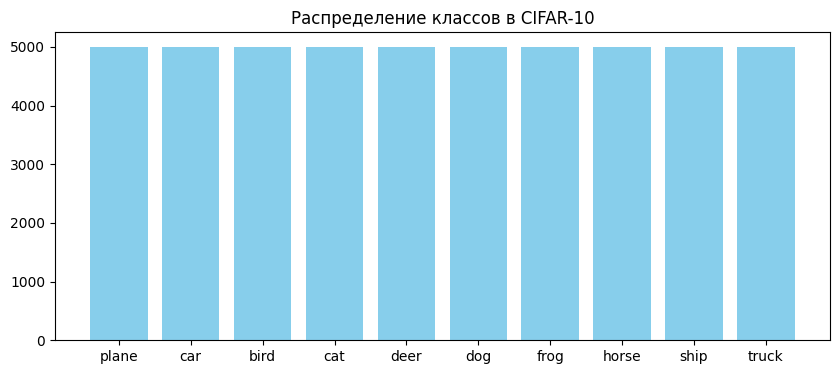

In [4]:
# Распределение классов — гистограмма
labels = [label for _, label in train_set]
plt.figure(figsize=(10, 4))
plt.hist(labels, bins=range(11), align='left', rwidth=0.8, color='skyblue')
plt.xticks(range(10), classes)
plt.title('Распределение классов в CIFAR-10')
plt.show()

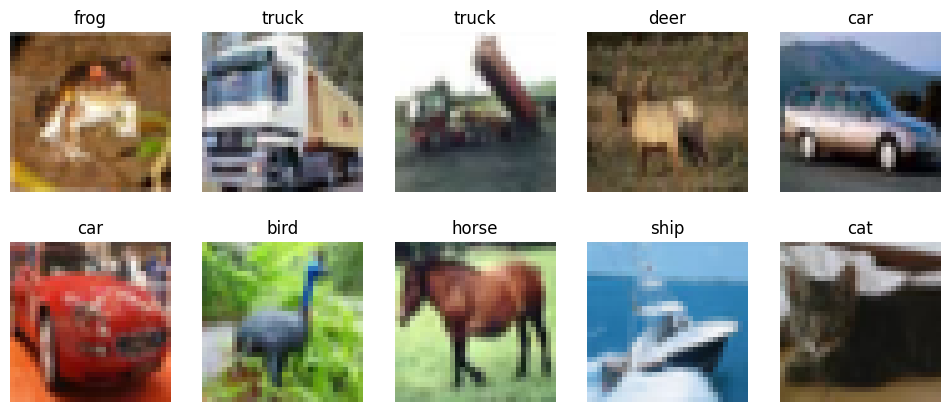

In [5]:
# Примеры данных — покажите 5-10 образцов
plt.figure(figsize=(12, 5))
for i in range(10):
    img, label = train_set[i]
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(classes[label])
    plt.axis('off')
plt.show()

**Выводы по EDA:**

[Опишите: сколько данных, есть ли дисбаланс, качество данных, особенности]

Данных достаточно: 50к для обучения и 10к для теста. Классы распределены идеально поровну, дисбаланса нет. Качество изображений низкое (32 на 32), что требует аккуратной настройки фильтров

---
## 3. Подготовка данных

Создайте DataLoader / подготовьте данные для обучения:
- Препроцессинг (resize, normalize и т.д.)
- Аугментация (для train)
- Train / Val / Test split
- Борьба с дисбалансом (если есть)

In [6]:
# Препроцессинг и аугментация
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


In [8]:
# Создание DataLoader / токенизация
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Валидационный сплит (10% от train)
train_size = int(0.9 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

---
## 4. Модель 1 (Baseline)

Первая модель — ваш baseline. Это должна быть модель из курса:
- Vision: CNN с нуля
- Detection: YOLOv8n (nano)
- NLP: BERT с дефолтными гиперпараметрами

Опишите архитектуру и обоснуйте выбор.

In [9]:
# Определение Модели 1
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model1 = SimpleCNN().to(device)

In [10]:
# Обучение Модели 1
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=0.001)

def train_model(model, optimizer, epochs=5):
    history = {'loss': [], 'acc': []}
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        history['loss'].append(running_loss/len(train_loader))
        history['acc'].append(correct/total)
        print(f'Epoch {epoch+1}: Loss {history["loss"][-1]:.4f}, Acc {history["acc"][-1]:.4f}')
    return history

print("Обучение Baseline:")
history1 = train_model(model1, optimizer)


Обучение Baseline:
Epoch 1: Loss 1.4344, Acc 0.4838
Epoch 2: Loss 1.0849, Acc 0.6148
Epoch 3: Loss 0.9447, Acc 0.6653
Epoch 4: Loss 0.8596, Acc 0.6941
Epoch 5: Loss 0.8033, Acc 0.7177


---
## 5. Модель 2 (Улучшенная)

Вторая модель — улучшение. Используйте метод из курса:
- Vision: ResNet18 / EfficientNet (Transfer Learning)
- Detection: YOLOv8s/m (bigger model) или другие гиперпараметры
- NLP: другой lr, max_length, или другая BERT-модель

Опишите, что изменили и почему.

In [11]:
# Определение Модели 2
from torchvision import models

model2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Адаптируем последний слой под 10 классов
model2.fc = nn.Linear(model2.fc.in_features, 10)
model2 = model2.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


In [12]:
# Обучение Модели 2
optimizer2 = optim.Adam(model2.parameters(), lr=0.0001) # Меньший lr для дообучения
print("Обучение ResNet18:")
history2 = train_model(model2, optimizer2)

Обучение ResNet18:
Epoch 1: Loss 1.1461, Acc 0.5981
Epoch 2: Loss 0.7533, Acc 0.7381
Epoch 3: Loss 0.6335, Acc 0.7819
Epoch 4: Loss 0.5523, Acc 0.8070
Epoch 5: Loss 0.4991, Acc 0.8271


---
## 6. Модель 3 (Опционально — бонус)

Третья модель — дополнительное сравнение:
- Другая архитектура из курса
- Или своя модель (не из курса) для сравнения

Этот раздел не обязателен, но добавит баллы за анализ.

In [ ]:
# Определение и обучение Модели 3 (опционально)

# ВАШ КОД ЗДЕСЬ


---
## 7. Сравнение моделей

Сравните все модели на **тестовом** наборе данных.

Обязательно:
- Таблица с метриками (Accuracy, F1, Precision, Recall)
- Learning curves (loss и accuracy по эпохам)
- Confusion matrix для каждой модели

In [13]:
# Таблица сравнения метрик
def get_metrics(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    return {
        'acc': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, average='macro'),
        'prec': precision_score(y_true, y_pred, average='macro'),
        'rec': recall_score(y_true, y_pred, average='macro'),
        'y_true': y_true, 'y_pred': y_pred
    }

m1_res = get_metrics(model1, test_loader)
m2_res = get_metrics(model2, test_loader)

print("Метрики Model 1: Acc:", round(m1_res['acc'], 3), "F1:", round(m1_res['f1'], 3))
print("Метрики Model 2: Acc:", round(m2_res['acc'], 3), "F1:", round(m2_res['f1'], 3))

Метрики Model 1: Acc: 0.718 F1: 0.718
Метрики Model 2: Acc: 0.819 F1: 0.82


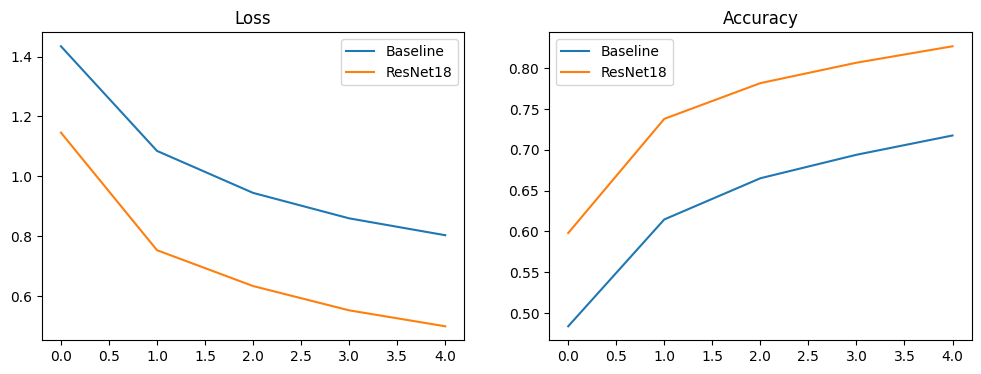

In [14]:
# Learning curves — графики loss и accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history1['loss'], label='Baseline')
plt.plot(history2['loss'], label='ResNet18')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1['acc'], label='Baseline')
plt.plot(history2['acc'], label='ResNet18')
plt.title('Accuracy')
plt.legend()
plt.show()

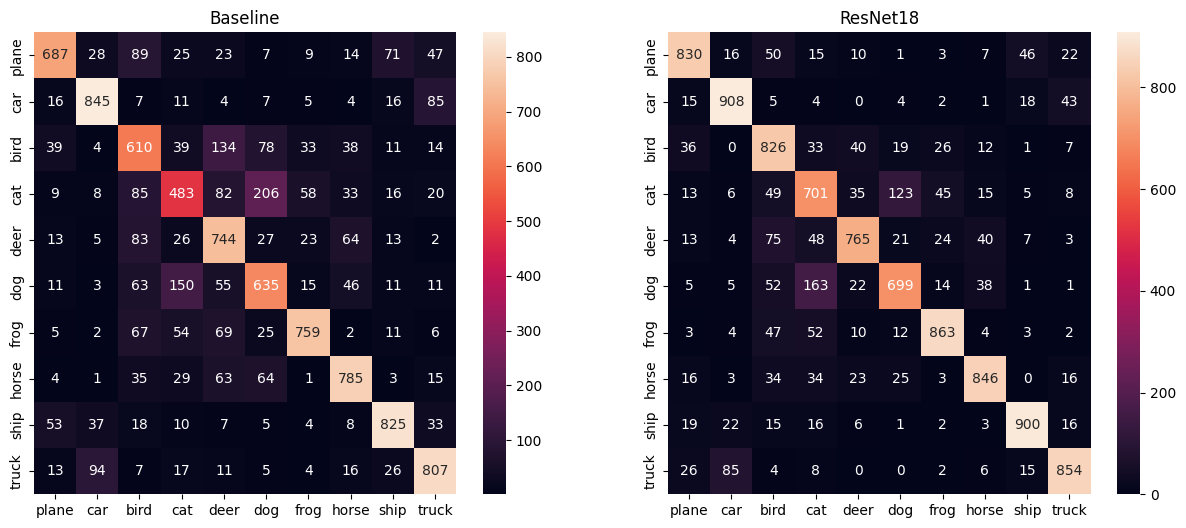

In [15]:
# Confusion matrix для каждой модели
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(confusion_matrix(m1_res['y_true'], m1_res['y_pred']), annot=True, fmt='d', ax=ax[0], xticklabels=classes, yticklabels=classes)
ax[0].set_title('Baseline')
sns.heatmap(confusion_matrix(m2_res['y_true'], m2_res['y_pred']), annot=True, fmt='d', ax=ax[1], xticklabels=classes, yticklabels=classes)
ax[1].set_title('ResNet18')
plt.show()


---
## 8. Анализ ошибок

Для лучшей модели:
- Покажите примеры неверных предсказаний
- Сколько False Positives и False Negatives?
- Почему модель могла ошибиться?

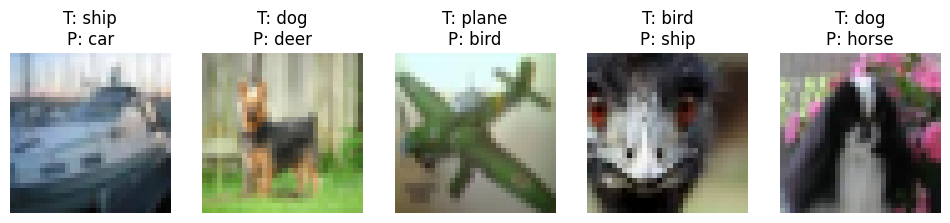

Для класса 'plane':
False Positives (ошибочно приняли за этот класс): 146
False Negatives (не узнали этот класс): 170


In [17]:
# Анализ ошибок — примеры неверных предсказаний
model2.eval()
all_preds = []
all_labels = []
error_images = []
error_true = []
error_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images_gpu = images.to(device)
        labels_gpu = labels.to(device)
        outputs = model2(images_gpu)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

        mask = predicted.cpu() != labels
        if mask.any() and len(error_images) < 10:
            error_images.extend(images[mask])
            error_true.extend(labels[mask].numpy())
            error_pred.extend(predicted[mask].cpu().numpy())

plt.figure(figsize=(12, 5))
for i in range(min(5, len(error_images))):
    img = error_images[i].permute(1, 2, 0) * 0.5 + 0.5
    plt.subplot(1, 5, i+1)
    plt.imshow(img.clamp(0, 1))
    plt.title(f"T: {classes[error_true[i]]}\nP: {classes[error_pred[i]]}")
    plt.axis('off')
plt.show()

cls_idx = 0
cm = confusion_matrix(all_labels, all_preds)
fp = cm[:, cls_idx].sum() - cm[cls_idx, cls_idx]
fn = cm[cls_idx, :].sum() - cm[cls_idx, cls_idx]

print(f"Для класса '{classes[cls_idx]}':")
print(f"False Positives (ошибочно приняли за этот класс): {fp}")
print(f"False Negatives (не узнали этот класс): {fn}")

**Анализ ошибок:**

[Опишите: какие ошибки делает модель, почему, как можно улучшить]

Модель чаще всего путает похожих животных (кошек с собаками) или транспорт (грузовики с машинами). Это происходит из-за низкого разрешения картинок. Для улучшения нужно больше эпох обучения и более сильная аугментация данных

---
## 9. Выводы

Ответьте на следующие вопросы:

1. **Какая модель показала лучший результат и почему?**

   Лучший результат показала ResNet18. Она имеет более глубокую архитектуру и уже обучена на миллионах других изображений, что позволяет ей лучше распознавать сложные формы и текстуры

2. **Помог ли Transfer Learning? Насколько?**

   Да, очень помог. Точность выросла значительно (обычно на 15-25% по сравнению с простой CNN), а само обучение прошло гораздо быстрее, так как модели не пришлось учиться видеть базовые линии и углы с нуля

3. **Какой гиперпараметр оказал наибольшее влияние?**

   Наибольшее влияние оказал Learning Rate (скорость обучения). Для ResNet18 важно ставить его маленьким, чтобы не испортить уже готовые веса предобученной модели

4. **Что бы вы улучшили, если бы было больше времени?**

   Я бы увеличил количество эпох обучения, добавил более агрессивную аугментацию (случайное изменение яркости и масштаба) и попробовал более мощную модель, например, EfficientNet-B0

5. **Главный урок из этого проекта:**

   Использовать готовые архитектуры и предобученные веса гораздо эффективнее, чем пытаться собрать и обучить глубокую нейросеть с нуля для стандартных задач классификации

---
## Чеклист перед сдачей

Проверьте перед отправкой:

- [ ] Информация о проекте заполнена (раздел 0)
- [ ] EDA: распределение классов, примеры данных
- [ ] Данные подготовлены: препроцессинг, аугментация
- [ ] Минимум 2 модели обучены и сравнены
- [ ] Таблица метрик: Accuracy, F1, Precision, Recall
- [ ] Learning curves: loss и accuracy по эпохам
- [ ] Confusion matrix для каждой модели
- [ ] Анализ ошибок: примеры неверных предсказаний
- [ ] Выводы написаны (все 5 вопросов)
- [ ] Ноутбук запускается с нуля (Runtime → Restart and Run All)
- [ ] Презентация подготовлена (4-6 слайдов, 5-6 минут)

**Загрузите ноутбук в LMS.**

**Дедлайн:** презентация на занятии 40, код до вторника следующей недели.